In [176]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [39]:
df=pd.read_csv(r"C:\Users\anant\Desktop\iris_processed.csv")
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [42]:
#averagde sepal length of all flowers
df["SepalLengthCm"].median()

5.8

In [44]:
#species having highest petal width
pw=df["PetalWidthCm"].median()
print("avg petal width",pw)

avg petal width 1.3


In [46]:
df[df["PetalWidthCm"]>1.3]["Species"]

50     Iris-versicolor
51     Iris-versicolor
52     Iris-versicolor
54     Iris-versicolor
56     Iris-versicolor
            ...       
145     Iris-virginica
146     Iris-virginica
147     Iris-virginica
148     Iris-virginica
149     Iris-virginica
Name: Species, Length: 72, dtype: object

In [48]:
#we can conclude that specied having highest petal width is  Iris-versicolor and  Iris-virginica

In [50]:
#min max accross species
df.loc[df["PetalLengthCm"] == df["PetalLengthCm"].max(), "Species"]


118    Iris-virginica
Name: Species, dtype: object

In [52]:
#min max accross species
df.loc[df["PetalLengthCm"] == df["PetalLengthCm"].min(), "Species"]

22    Iris-setosa
Name: Species, dtype: object

In [54]:
# Range (min, max) of petal length across species
print(df.groupby("Species")["PetalLengthCm"].agg(["min", "max"]))

                 min  max
Species                  
Iris-setosa      1.0  1.9
Iris-versicolor  3.0  5.1
Iris-virginica   4.5  6.9


In [65]:
print(df.groupby("Species")["SepalWidthCm"].var())

Species
Iris-setosa        0.145180
Iris-versicolor    0.098469
Iris-virginica     0.104004
Name: SepalWidthCm, dtype: float64


In [71]:
print(df.groupby("Species")["SepalWidthCm"].median())

Species
Iris-setosa        3.4
Iris-versicolor    2.8
Iris-virginica     3.0
Name: SepalWidthCm, dtype: float64


In [ ]:
#no but their average is nearly same

In [67]:
import pandas as pd

# Assuming df has columns 'sepal_length' and 'petal_length'

correlation = df["SepalLengthCm"].corr(df["PetalLengthCm"])
print("Correlation coefficient:", correlation)

if correlation > 0:
    print("There is a positive correlation between sepal length and petal length.")
elif correlation < 0:
    print("There is a negative correlation between sepal length and petal length.")
else:
    print("There is no correlation between sepal length and petal length.")


Correlation coefficient: 0.8717541573048718
There is a positive correlation between sepal length and petal length.


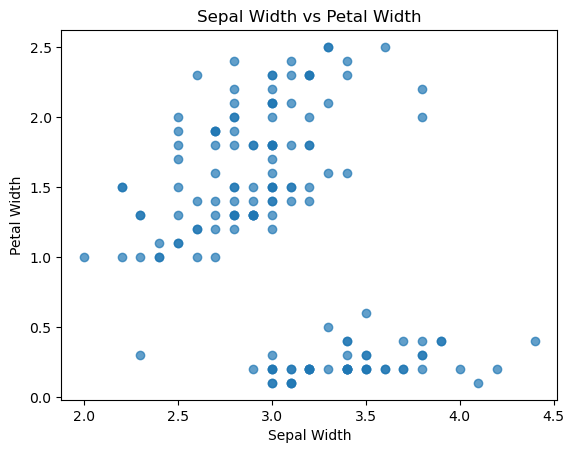

In [73]:
#does sepel width coorelate with petal width
plt.scatter(df["SepalWidthCm"], df["PetalWidthCm"], alpha=0.7)
plt.xlabel("Sepal Width")
plt.ylabel("Petal Width")
plt.title("Sepal Width vs Petal Width")
plt.show()


In [75]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Assuming your DataFrame is df and has 'sepal_width' and 'petal_width'

# Pearson correlation
corr, p_value = pearsonr(df["SepalWidthCm"], df["PetalWidthCm"])

print("Correlation coefficient (r):", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Yes, sepal width and petal width are significantly correlated.")
else:
    print("No, sepal width and petal width are not significantly correlated.")


Correlation coefficient (r): -0.3565440896138058
P-value: 7.523890956067524e-06
Yes, sepal width and petal width are significantly correlated.


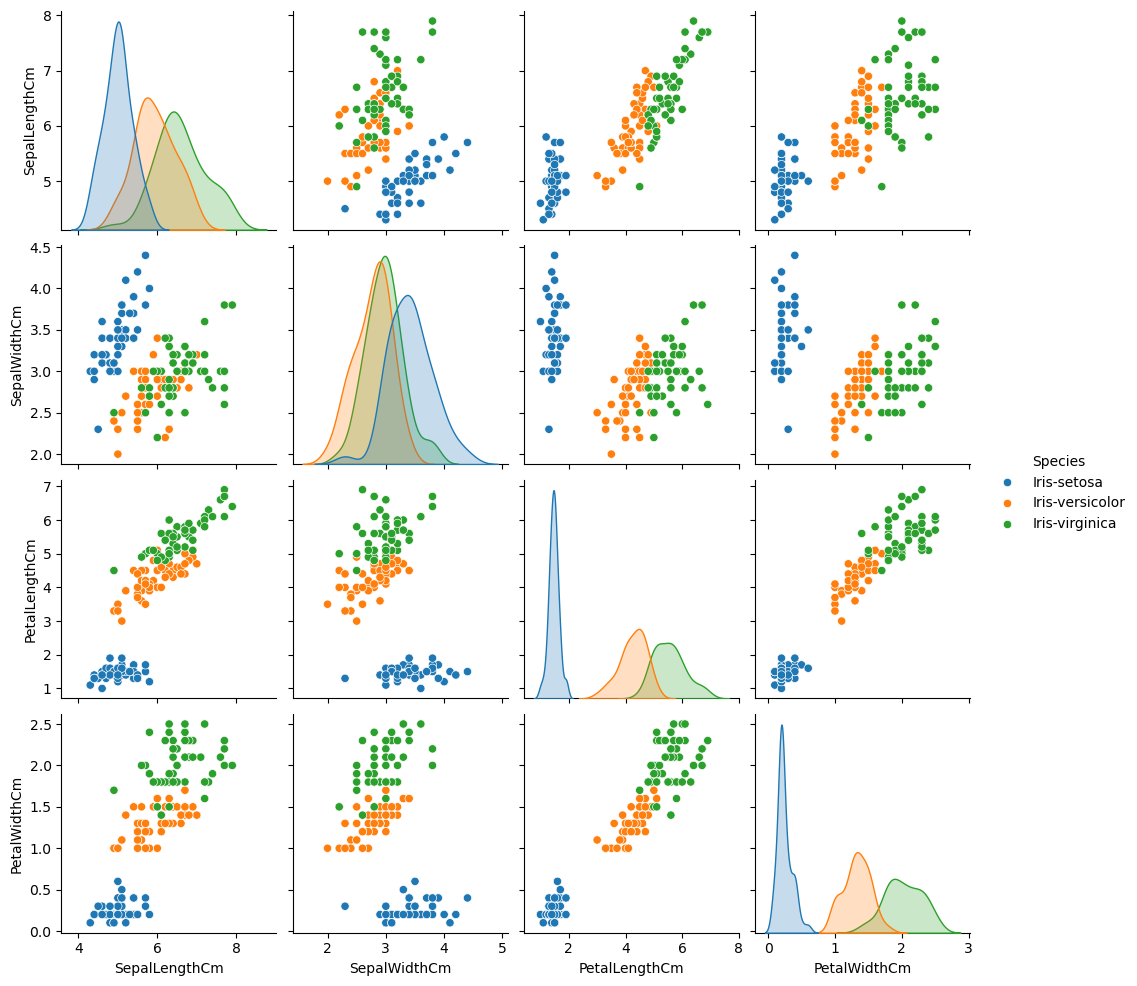

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="Species", diag_kind="kde")
plt.show()



In [20]:
#it shows which attributes makes more prediction

In [81]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])


In [103]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [105]:
df.isnull().sum()


SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [107]:
df.dtypes


SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species            int32
dtype: object

In [109]:
df.duplicated().sum()


3

In [111]:
df[df.duplicated()]


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
34,4.9,3.1,1.5,0.1,0
37,4.9,3.1,1.5,0.1,0
142,5.8,2.7,5.1,1.9,2


In [113]:
#dropping duplicates

In [115]:
df.drop_duplicates(inplace=True)

In [117]:
df.duplicated().sum()


0

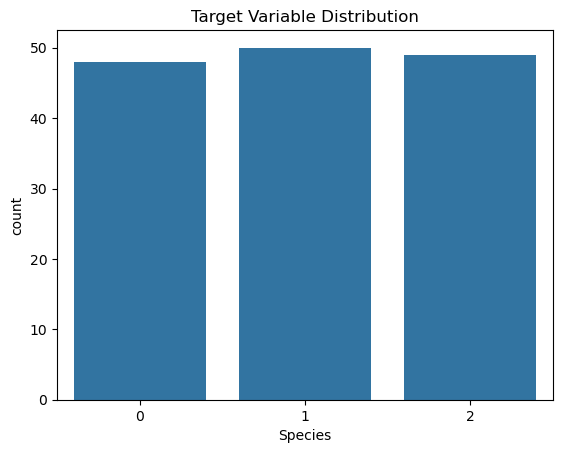

In [119]:
sns.countplot(x='Species', data=df)
plt.title("Target Variable Distribution")
plt.show()


In [121]:
#less data imbalance

In [123]:
#here the more amount of data is nonlinear so spearman correlation is applied
feature_target_corr = df.corr(method='spearman')['Species'].sort_values(ascending=False)

print("Correlation of features with target:")
print(feature_target_corr)

Correlation of features with target:
Species          1.000000
PetalWidthCm     0.937556
PetalLengthCm    0.934945
SepalLengthCm    0.797145
SepalWidthCm    -0.427530
Name: Species, dtype: float64


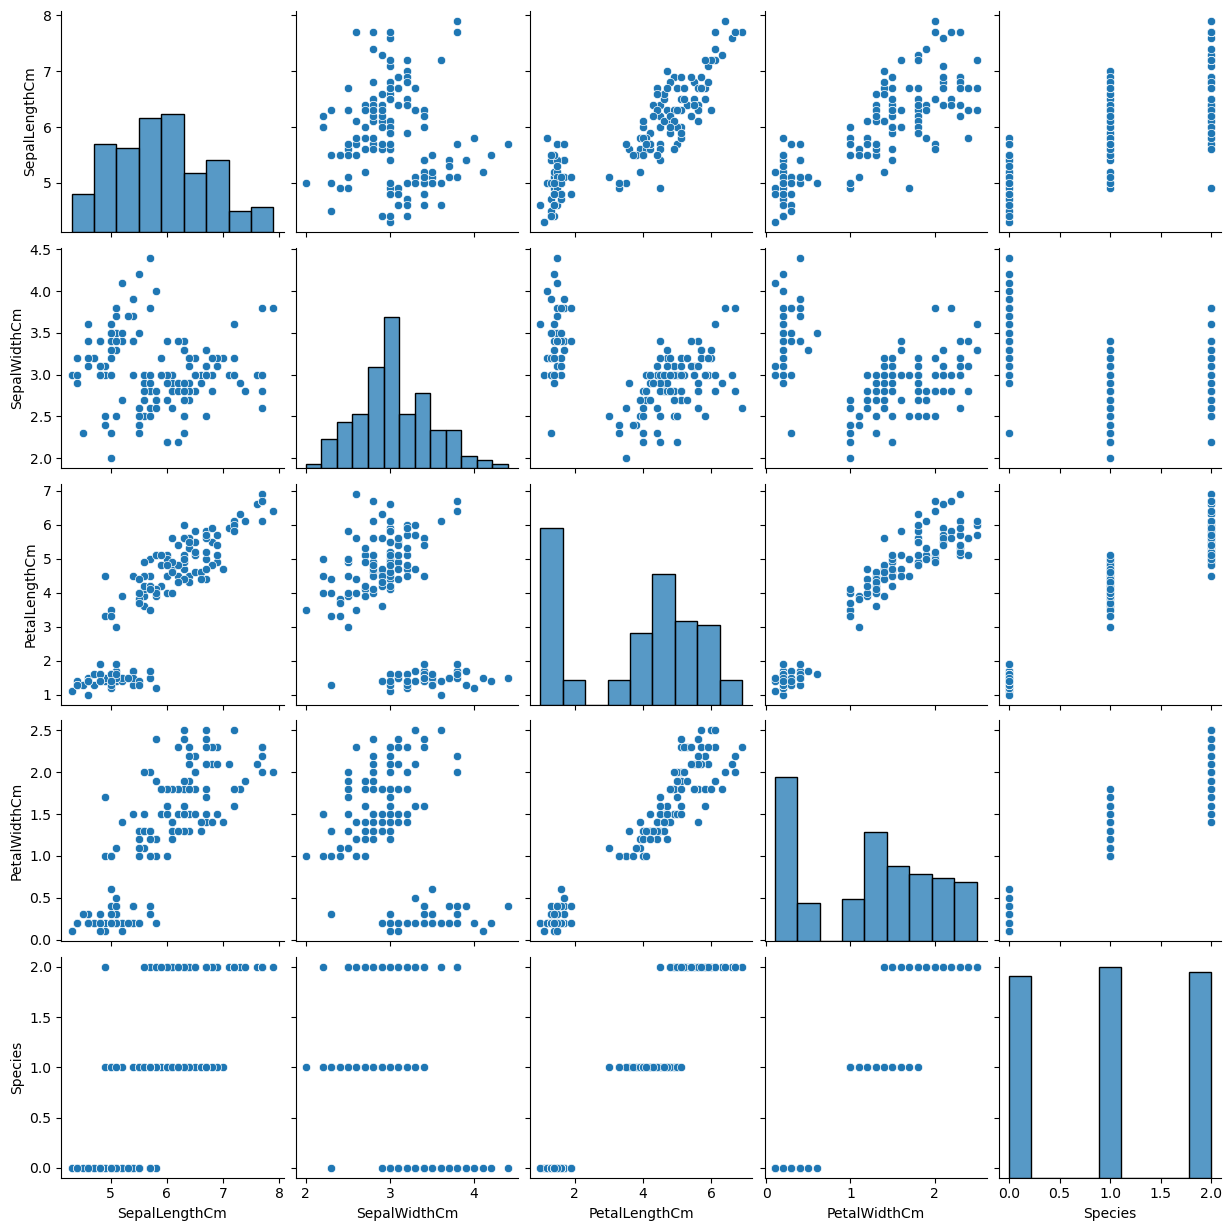

In [129]:
sns.pairplot(df)

In [131]:
# Dependent variable (target)
y = df['Species']

# Independent variables (features)
X = df[['PetalWidthCm', 'PetalLengthCm', 'SepalLengthCm']]


Applying stratified k-fold

In [141]:

# Initialize stratified k-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
conf_matrices = []
for train_index, test_index in skf.split(X, y):
    # Split data
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    

In [172]:
train_index

array([  0,   2,   4,   5,   6,   7,   8,   9,  10,  11,  12,  14,  15,
        16,  18,  19,  20,  21,  22,  24,  25,  26,  27,  28,  29,  30,
        32,  33,  34,  35,  36,  38,  39,  40,  42,  43,  45,  46,  47,
        50,  51,  52,  53,  54,  56,  57,  58,  59,  61,  63,  64,  65,
        66,  67,  70,  71,  72,  73,  74,  75,  76,  78,  79,  80,  81,
        82,  84,  85,  86,  88,  89,  90,  91,  92,  93,  94,  95,  96,
        97, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
       113, 114, 115, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
       128, 129, 130, 132, 133, 135, 136, 137, 139, 141, 142, 144, 145,
       146])

In [174]:
test_index

array([  1,   3,  13,  17,  23,  31,  37,  41,  44,  48,  49,  55,  60,
        62,  68,  69,  77,  83,  87,  98,  99, 112, 116, 127, 131, 134,
       138, 140, 143])

In [145]:
# Create model
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

In [147]:
# Train
model.fit(X_train, y_train)
    

C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [149]:
# Predict
y_pred = model.predict(X_test)

In [151]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 2,
       2, 2, 1, 2, 2, 2, 2])

In [153]:
# Evaluate
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [155]:
accuracies.append(acc)
conf_matrices.append(cm)

In [157]:
# Average accuracy across folds
print("Average Accuracy:", np.mean(accuracies))

# Show confusion matrix from the last fold
print("\nConfusion Matrix (last fold):")
print(conf_matrices[-1])


Average Accuracy: 0.9310344827586207

Confusion Matrix (last fold):
[[9 0 0]
 [0 9 1]
 [0 1 9]]


# Leave-One-Out Cross Validation

In [163]:
# Initialize Leave-One-Out Cross Validator
loo = LeaveOneOut()


In [165]:
# Compute cross-validation scores
scores = cross_val_score(model, X, y, cv=loo, scoring='accuracy')


C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in versio

In [167]:
# Results
print("Number of samples:", len(scores))
print("Mean Accuracy:", np.mean(scores))
print("Standard Deviation:", np.std(scores))

Number of samples: 147
Mean Accuracy: 0.9591836734693877
Standard Deviation: 0.19786448397617673


In [182]:
cm = confusion_matrix(y_test, y_pred)

In [190]:
print("\n📊 Confusion Matrix:")
print(cm)


📊 Confusion Matrix:
[[48  0  0]
 [ 0 47  3]
 [ 0  3 46]]


In [192]:
# Initialize LOOCV and model
loo = LeaveOneOut()
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# Store actual and predicted values
y_true = []
y_pred = []

# Leave-One-Out loop
for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    y_true.append(y_test.values[0])
    y_pred.append(pred[0])

C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in versio

In [193]:
# Evaluate results
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

print("✅ Leave-One-Out Accuracy:", acc)
print("\n📊 Confusion Matrix:")
print(cm)
print("\n📈 Classification Report:")
print(report)

✅ Leave-One-Out Accuracy: 0.9591836734693877

📊 Confusion Matrix:
[[48  0  0]
 [ 0 47  3]
 [ 0  3 46]]

📈 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       0.94      0.94      0.94        50
           2       0.94      0.94      0.94        49

    accuracy                           0.96       147
   macro avg       0.96      0.96      0.96       147
weighted avg       0.96      0.96      0.96       147



In [196]:
#by applying leave one out  data for prediction we get a model accuracy of 0.95 as compared to stratified k fold with linear regression